# FGSM for Regression: Inflating a Predicted House Value

FGSM in the vision repo takes one gradient-sign step to push a classifier's *loss* up, away from the correct class. There is no "correct class" here, only a continuous predicted value, so the natural adaptation is to step directly in the direction that increases the model's *output*: `x_adv = x + epsilon * sign(grad of price w.r.t. x)`, ascending the price itself rather than any loss. The realistic version of this attacker is not trying to fool a human's eyes; it is trying to game an automated valuation model into over-appraising a property, by slightly misreporting a handful of numeric inputs that individually still look plausible.

That "individually still look plausible" constraint is the genuinely new, domain-specific part of this notebook: not every feature is something an attacker could plausibly change. Latitude, longitude, and the census block's population are not under an individual's control to misreport about their own house; median income, house age, and room/bedroom/occupancy counts are exactly the kind of self-reported numbers that appear on a mortgage or appraisal form. The attack below is masked to perturb only that reportable subset, leaving the rest of the input untouched.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

### Setup: Load the Trained Model
Same `HousePriceNet` architecture and standardization trained in `models/01_train_regressor.ipynb`,
loading its saved weights and scaler parameters rather than retraining.

In [2]:
class HousePriceNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

checkpoint = torch.load('../models/house_price_net.pth', weights_only=False)
FEATURE_NAMES = checkpoint['feature_names']
scaler_mean = checkpoint['scaler_mean']
scaler_scale = checkpoint['scaler_scale']

model = HousePriceNet(n_features=len(FEATURE_NAMES))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded house_price_net.pth - {len(FEATURE_NAMES)} features: {FEATURE_NAMES}")

def standardize(x_raw):
    return (x_raw - scaler_mean) / scaler_scale

def unstandardize(x_scaled):
    return x_scaled * scaler_scale + scaler_mean

Loaded house_price_net.pth - 8 features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### Setup: Test Houses and the Reportable Feature Mask
A real sample of test-set houses, not hand-picked. `PERTURBABLE_FEATURES` names the subset an
individual could plausibly misreport about their own property; `Population`, `Latitude`, and
`Longitude` are excluded since they are not self-reported facts about a specific house.

In [3]:
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

SAMPLE_SIZE = 100
sample_idx = X_test.index[:SAMPLE_SIZE]
X_sample = X_test.loc[sample_idx].values.astype(np.float32)

PERTURBABLE_FEATURES = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']
perturb_mask = np.array([1.0 if f in PERTURBABLE_FEATURES else 0.0 for f in FEATURE_NAMES], dtype=np.float32)

# Real observed range per feature, so a perturbed value stays within what the raw dataset actually
# contains (no negative room counts, no negative occupancy) instead of only being bounded in
# standardized-epsilon terms, which says nothing about whether the raw value is physically sensible.
feature_min = X.min(axis=0).values.astype(np.float32)
feature_max = X.max(axis=0).values.astype(np.float32)

print(f"Perturbable: {PERTURBABLE_FEATURES}")
print(f"Frozen (not self-reportable): {[f for f in FEATURE_NAMES if f not in PERTURBABLE_FEATURES]}")
print(f"Evaluating on {len(X_sample)} real test-set houses")

Perturbable: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']
Frozen (not self-reportable): ['Population', 'Latitude', 'Longitude']
Evaluating on 100 real test-set houses


### The Attack
A single gradient-sign step on the standardized input, masked so it only ever touches the
perturbable features, then un-standardized back to real units for reporting. $\varepsilon$ is
expressed in standardized units (one full $\varepsilon=1.0$ is a one-standard-deviation change in
each perturbed feature), the same convention that makes an epsilon meaningfully comparable across
inputs on wildly different natural scales.

In [4]:
def fgsm_inflate(x_scaled, epsilon, mask):
    x = torch.tensor(x_scaled, dtype=torch.float32, requires_grad=True)
    price = model(x.unsqueeze(0))
    price.backward()  # ascend the price directly: no sign flip needed, unlike a loss being minimized
    grad = x.grad.numpy()
    perturbation = epsilon * np.sign(grad) * mask
    x_adv_scaled = x_scaled + perturbation

    # Clip in raw units to the dataset's real observed range, so "epsilon=1.0" cannot report a
    # physically nonsensical value (e.g. negative average occupancy) just because it is only one
    # standard deviation away in standardized space.
    x_adv_raw = unstandardize(x_adv_scaled)
    x_adv_raw = np.clip(x_adv_raw, feature_min, feature_max)
    return standardize(x_adv_raw)

x_example_scaled = standardize(X_sample[0])
orig_price = model(torch.tensor(x_example_scaled, dtype=torch.float32).unsqueeze(0)).item() * 100_000
adv_scaled = fgsm_inflate(x_example_scaled, epsilon=0.5, mask=perturb_mask)
adv_price = model(torch.tensor(adv_scaled, dtype=torch.float32).unsqueeze(0)).item() * 100_000

print(f"Original predicted value: ${orig_price:,.0f}")
print(f"Adversarial predicted value (epsilon=0.5): ${adv_price:,.0f}  ({100 * (adv_price / orig_price - 1):+.1f}%)")

comparison = pd.DataFrame({
    'Feature': FEATURE_NAMES,
    'Original': X_sample[0],
    'Reported (adversarial)': unstandardize(adv_scaled),
})
comparison

Original predicted value: $62,486
Adversarial predicted value (epsilon=0.5): $177,190  (+183.6%)


,Feature,Original,Reported (adversarial)
0,MedInc,1.681200,2.633318
1,HouseAge,25.000000,18.698941
2,AveRooms,4.192201,2.998549
3,AveBedrms,1.022284,1.238885
4,Population,1392.000000,1392.000000
5,AveOccup,3.877437,0.692308
6,Latitude,36.060001,36.060001
7,Longitude,-119.010002,-119.010002


### Evaluation: Price Inflation vs. $\varepsilon$
Every house in the sample, attacked at each $\varepsilon$, reporting the average percentage price
inflation achieved and a threshold-based Attack Success Rate (inflating the predicted price by more
than 10%), the closest tabular analogue of the "ASR" reported throughout the rest of this repo
family, since a continuous regression output has no single natural success/failure line.

In [5]:
EPSILONS = [0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
SUCCESS_THRESHOLD_PCT = 10.0

rows = []
for x_raw in X_sample:
    x_scaled = standardize(x_raw)
    orig_price = model(torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0)).item()
    if orig_price <= 0:
        continue

    for epsilon in EPSILONS:
        adv_scaled = fgsm_inflate(x_scaled, epsilon, perturb_mask)
        adv_price = model(torch.tensor(adv_scaled, dtype=torch.float32).unsqueeze(0)).item()
        pct_inflation = 100 * (adv_price / orig_price - 1)
        rows.append({
            'Epsilon': epsilon, 'Pct_Inflation': pct_inflation,
            'Success': pct_inflation > SUCCESS_THRESHOLD_PCT,
        })

results_df = pd.DataFrame(rows)
results_df.to_csv('fgsm_inflation_results.csv', index=False)
summary = results_df.groupby('Epsilon').agg(Avg_Pct_Inflation=('Pct_Inflation', 'mean'), ASR=('Success', 'mean'))
summary['ASR'] = summary['ASR'] * 100
summary.round(2)

,Avg_Pct_Inflation,ASR
Epsilon,,
0.05,10.56,52.0
0.10,21.66,96.0
0.20,42.99,100.0
0.30,59.50,100.0
0.50,85.97,100.0
1.00,145.38,100.0


### Plot: Inflation and ASR vs. Perturbation Budget

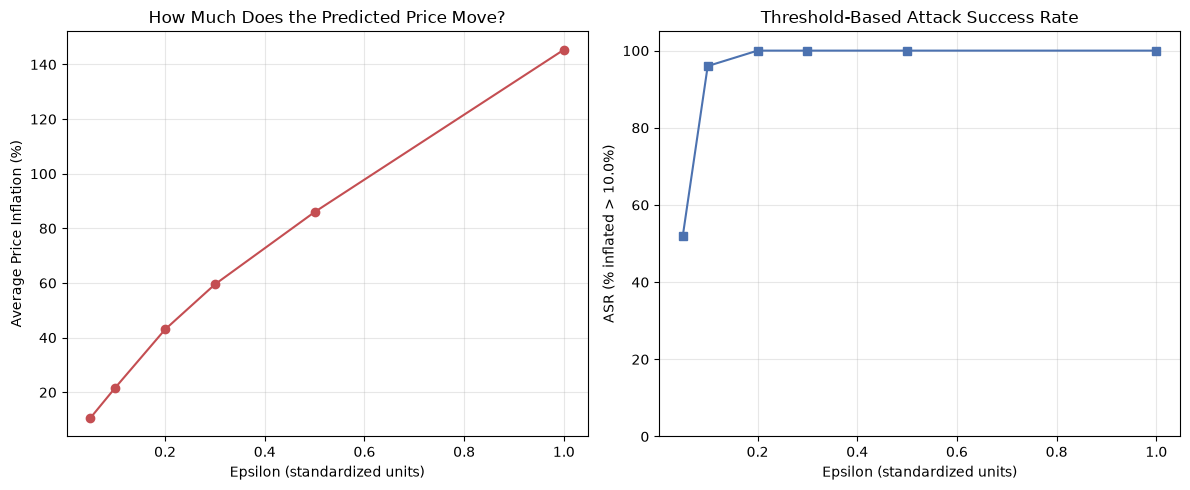

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(summary.index, summary['Avg_Pct_Inflation'], 'o-', color='#C44E52')
axes[0].set_xlabel('Epsilon (standardized units)')
axes[0].set_ylabel('Average Price Inflation (%)')
axes[0].set_title('How Much Does the Predicted Price Move?')
axes[0].grid(alpha=0.3)

axes[1].plot(summary.index, summary['ASR'], 's-', color='#4C72B0')
axes[1].set_xlabel('Epsilon (standardized units)')
axes[1].set_ylabel(f'ASR (% inflated > {SUCCESS_THRESHOLD_PCT}%)')
axes[1].set_title('Threshold-Based Attack Success Rate')
axes[1].set_ylim(0, 105)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()